In [22]:
import xarray as xr
import matplotlib.pyplot as plt
from dask.distributed import Client
import matplotlib.animation as animation
import numpy as np
import os
import xesmf as xe
import intake

In [23]:
root_dir = "/g/data/jk72/mxr581/SOTS-project-data/regional-model-output"

run_dirs = ["output009", "output010", "output011", "output012"]

fname_temp = "access-om3.mom6.region.3d.temp.z.1day.mean._2170.nc"
fname_surf = "access-om3.mom6.2d.1day.mean._2170.nc"


In [24]:
# 3D temp
temp_paths = [os.path.join(root_dir, r, fname_temp) for r in run_dirs]
temp_paths
# 2D surface
surf_paths = [os.path.join(root_dir, r, fname_surf) for r in run_dirs]
surf_paths

['/g/data/jk72/mxr581/SOTS-project-data/regional-model-output/output009/access-om3.mom6.2d.1day.mean._2170.nc',
 '/g/data/jk72/mxr581/SOTS-project-data/regional-model-output/output010/access-om3.mom6.2d.1day.mean._2170.nc',
 '/g/data/jk72/mxr581/SOTS-project-data/regional-model-output/output011/access-om3.mom6.2d.1day.mean._2170.nc',
 '/g/data/jk72/mxr581/SOTS-project-data/regional-model-output/output012/access-om3.mom6.2d.1day.mean._2170.nc']

In [25]:
ds_temp_9m = xr.concat([xr.open_dataset(p) for p in temp_paths], dim="time")
ds_surf_9m = xr.concat([xr.open_dataset(p) for p in surf_paths], dim="time")

print(ds_temp_9m.time.size, ds_surf_9m.time.size)


/jobfs/157691567.gadi-pbs/ipykernel_2249980/1129759774.py:1: FutureWarning: In a future version, xarray will not decode the variable 'average_DT' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_temp_9m = xr.concat([xr.open_dataset(p) for p in temp_paths], dim="time")
/jobfs/157691567.gadi-pbs/ipykernel_2249980/1129759774.py:1: FutureWarning: In a future version, xarray will not decode the variable 'average_DT' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 

365 365


In [26]:
# -------------------------
# Settings
# -------------------------
XH_IDX, YH_IDX = 25, 33         # ds_temp_9m: isel grid point
XH_SOTS, YH_SOTS = 141.9, -47   # ds_surf_9m: nearest mlotst point

Z_MAX = 600.0
Z_MIN = 10.0

DT_THRESH = 0.3
GRAD_THRESH = 0.005

# -------------------------
# Helpers
# -------------------------
def guess_depth_dim(da):
    for cand in ["z_l", "z_l_1", "z", "depth", "st_ocean"]:
        if cand in da.dims:
            return cand
    non_time = [d for d in da.dims if d not in ["time", "TIME"]]
    if len(non_time) == 1:
        return non_time[0]
    raise ValueError(f"Cannot guess depth dim from dims={da.dims}")

def guess_time_dim(da):
    for cand in ["time", "TIME"]:
        if cand in da.dims:
            return cand
    raise ValueError(f"Cannot guess time dim from dims={da.dims}")

# -------------------------
# Extract SOTS temperature section (depth x time)
# -------------------------
temp_point_9m = ds_temp_9m["temp"].isel(xh_sub02=XH_IDX, yh_sub02=YH_IDX)
zdim = guess_depth_dim(temp_point_9m)
tdim = guess_time_dim(temp_point_9m)

temp_point_9m = temp_point_9m.sel({zdim: slice(0, Z_MAX)})

# Density-based MLD time series
MLD_sigma = ds_surf_9m["mlotst"].sel(xh=XH_SOTS, yh=YH_SOTS, method="nearest")


Method 1: MLD from ΔT = 0.3°C

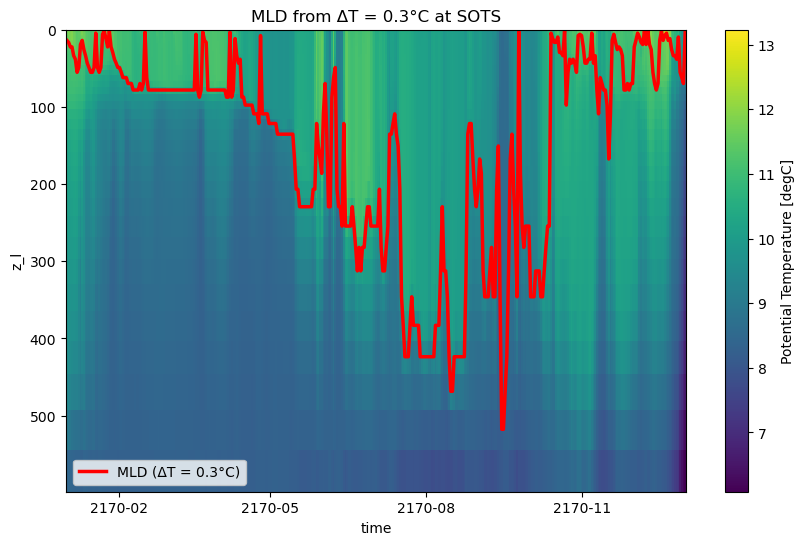

In [27]:
T_surface = temp_point_9m.isel({zdim: 0})
dT = temp_point_9m - T_surface
mld_dt = temp_point_9m[zdim].where(dT <= -DT_THRESH).min(dim=zdim)

fig, ax = plt.subplots(figsize=(10, 6))
temp_point_9m.plot(x=tdim, y=zdim, ax=ax, cmap="viridis")
mld_dt.plot(ax=ax, color="red", linewidth=2.5, label="MLD (ΔT = 0.3°C)")
ax.invert_yaxis()
ax.legend()
ax.set_title("MLD from ΔT = 0.3°C at SOTS")
plt.show()


Method 2: MLD from Gradient Threshold

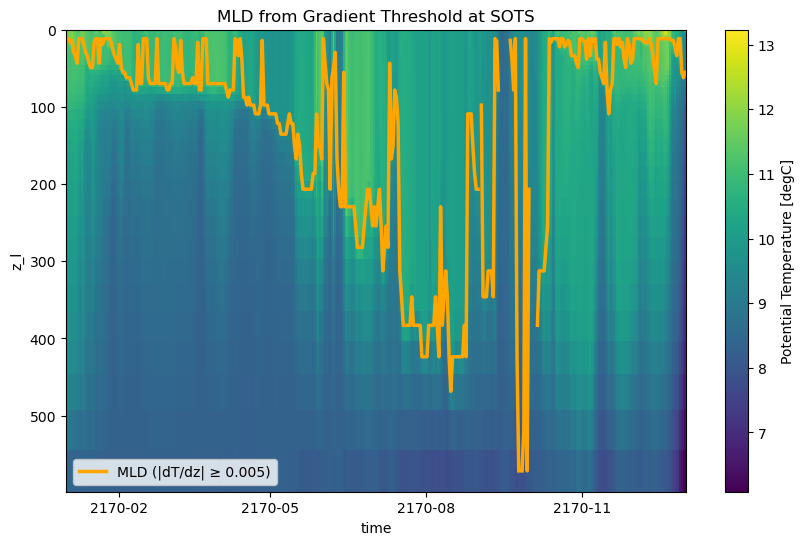

In [28]:
z = temp_point_9m[zdim]
dTdz = temp_point_9m.diff(dim=zdim) / z.diff(dim=zdim)

# mid-layer depth coords (align with dTdz)
z_mid = z.isel({zdim: slice(1, None)})
dTdz = dTdz.assign_coords({zdim: z_mid})

# apply z>=10m to avoid DWL/noise
dTdz_cut = dTdz.where(dTdz[zdim] >= Z_MIN)

mld_grad = dTdz_cut[zdim].where(np.abs(dTdz_cut) >= GRAD_THRESH).min(dim=zdim)
mld_grad = mld_grad.where(mld_grad >= Z_MIN)

fig, ax = plt.subplots(figsize=(10, 6))
temp_point_9m.plot(x=tdim, y=zdim, ax=ax, cmap="viridis")
mld_grad.plot(ax=ax, color="orange", linewidth=2.5, label="MLD (|dT/dz| ≥ 0.005)")
ax.invert_yaxis()
ax.legend()
ax.set_title("MLD from Gradient Threshold at SOTS")
plt.show()


Method 3: MLD from maximum |dT/dz|

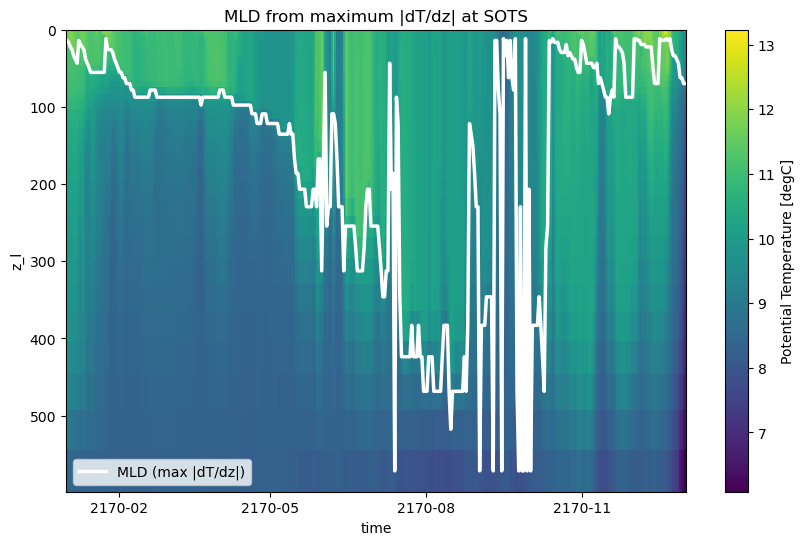

In [29]:
z = temp_point_9m[zdim]
dTdz = temp_point_9m.diff(dim=zdim) / z.diff(dim=zdim)

z_mid = z.isel({zdim: slice(1, None)})
dTdz = dTdz.assign_coords({zdim: z_mid})

abs_dTdz_cut = np.abs(dTdz.where(dTdz[zdim] >= Z_MIN))
mld_maxgrad = abs_dTdz_cut.idxmax(dim=zdim)
mld_maxgrad = mld_maxgrad.where(mld_maxgrad >= Z_MIN)

fig, ax = plt.subplots(figsize=(10, 6))
temp_point_9m.plot(x=tdim, y=zdim, ax=ax, cmap="viridis")
mld_maxgrad.plot(ax=ax, color="white", linewidth=2.5, label="MLD (max |dT/dz|)")
ax.invert_yaxis()
ax.legend()
ax.set_title("MLD from maximum |dT/dz| at SOTS")
plt.show()


Density-based vs Combined

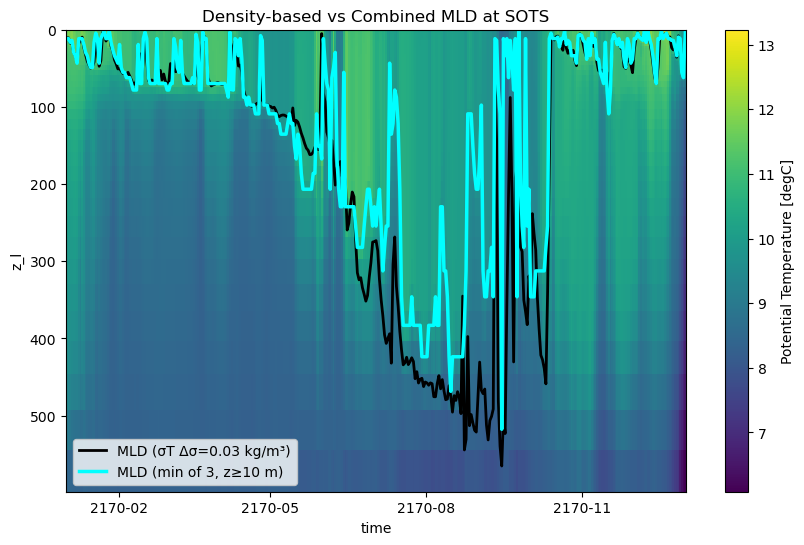

In [30]:
# Recompute 3 methods (so this cell is self-contained)
T_surface = temp_point_9m.isel({zdim: 0})
dT = temp_point_9m - T_surface
mld_dt = temp_point_9m[zdim].where(dT <= -DT_THRESH).min(dim=zdim)

z = temp_point_9m[zdim]
dTdz = temp_point_9m.diff(dim=zdim) / z.diff(dim=zdim)
z_mid = z.isel({zdim: slice(1, None)})
dTdz = dTdz.assign_coords({zdim: z_mid})

dTdz_cut = dTdz.where(dTdz[zdim] >= Z_MIN)
mld_grad = dTdz_cut[zdim].where(np.abs(dTdz_cut) >= GRAD_THRESH).min(dim=zdim)
mld_grad = mld_grad.where(mld_grad >= Z_MIN)

abs_dTdz_cut = np.abs(dTdz.where(dTdz[zdim] >= Z_MIN))
mld_maxgrad = abs_dTdz_cut.idxmax(dim=zdim)
mld_maxgrad = mld_maxgrad.where(mld_maxgrad >= Z_MIN)

MLD_combined = xr.concat([mld_dt, mld_grad, mld_maxgrad], dim="method").min("method")

MLD_sigma_aligned, MLD_combined_aligned = xr.align(MLD_sigma, MLD_combined, join="inner")

fig, ax = plt.subplots(figsize=(10, 6))
temp_point_9m.plot(x=tdim, y=zdim, ax=ax, cmap="viridis")
MLD_sigma_aligned.plot(ax=ax, color="black", linewidth=2, label="MLD (σT Δσ=0.03 kg/m³)")
MLD_combined_aligned.plot(ax=ax, color="cyan", linewidth=2.5, label="MLD (min of 3, z≥10 m)")
ax.invert_yaxis()
ax.legend()
ax.set_title("Density-based vs Combined MLD at SOTS")
plt.show()


Scatter + Correlation

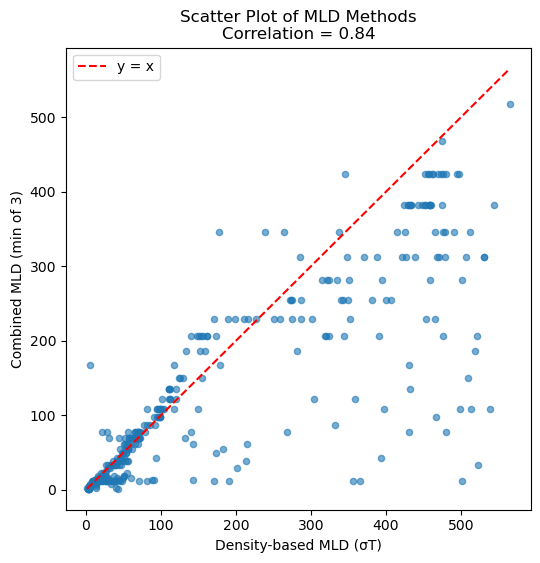

Correlation: 0.8374941495580837


In [31]:
# Recompute combined + align (self-contained)
T_surface = temp_point_9m.isel({zdim: 0})
dT = temp_point_9m - T_surface
mld_dt = temp_point_9m[zdim].where(dT <= -DT_THRESH).min(dim=zdim)

z = temp_point_9m[zdim]
dTdz = temp_point_9m.diff(dim=zdim) / z.diff(dim=zdim)
z_mid = z.isel({zdim: slice(1, None)})
dTdz = dTdz.assign_coords({zdim: z_mid})

dTdz_cut = dTdz.where(dTdz[zdim] >= Z_MIN)
mld_grad = dTdz_cut[zdim].where(np.abs(dTdz_cut) >= GRAD_THRESH).min(dim=zdim)
mld_grad = mld_grad.where(mld_grad >= Z_MIN)

abs_dTdz_cut = np.abs(dTdz.where(dTdz[zdim] >= Z_MIN))
mld_maxgrad = abs_dTdz_cut.idxmax(dim=zdim)
mld_maxgrad = mld_maxgrad.where(mld_maxgrad >= Z_MIN)

MLD_combined = xr.concat([mld_dt, mld_grad, mld_maxgrad], dim="method").min("method")
MLD_sigma_aligned, MLD_combined_aligned = xr.align(MLD_sigma, MLD_combined, join="inner")

corr_val = float(xr.corr(MLD_sigma_aligned, MLD_combined_aligned).values)

x = MLD_sigma_aligned.values
y = MLD_combined_aligned.values
mask = np.isfinite(x) & np.isfinite(y)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x[mask], y[mask], s=20, alpha=0.6)

min_val = min(np.nanmin(x[mask]), np.nanmin(y[mask]))
max_val = max(np.nanmax(x[mask]), np.nanmax(y[mask]))
ax.plot([min_val, max_val], [min_val, max_val], "r--", label="y = x")

ax.set_xlabel("Density-based MLD (σT)")
ax.set_ylabel("Combined MLD (min of 3)")
ax.set_title(f"Scatter Plot of MLD Methods\nCorrelation = {corr_val:.2f}")
ax.legend()
plt.show()

print("Correlation:", corr_val)
